# Feature-axis validation — is `design_name` really the right client axis?

Systematic re-check of the Phase-2/3 conclusion. Build size-invariant per-sample
descriptors, then run PCA + probes + variance decomposition against every metadata
factor. Whichever factor consistently explains the layout structure earns the FL
client axis; if something else (e.g. the `-a`/`-b` variant, macro geometry, or a
flow attribute in disguise) explains more, that's the honest partition axis.

## Predictions (frozen before running anything)

1. **PC1 ≈ macro / channel geometry** (macro-area fraction, distance-transform
   median of free space). Splits `-a` from `-b` almost perfectly.
2. **PC2 ≈ design scale**, ordering zero-riscy → RISCY → RISCY-FPU.
3. **Utilization** appears as a *smooth gradient*, not clusters.
4. **Power mesh** is near-invisible in routability features (would only show up
   in IR-drop channels, which the DRC feature set does not carry).
5. **Macro placement** sits between design and flow: enough spatial effect to
   move a point, not enough to redefine the cluster.

If any diagnostic contradicts the list, that is a finding — not a signal to
re-tune the pipeline.

## Workflow

1. Parse filenames into a factorial design matrix (already covered in the
   feature-analysis notebooks — repeated inline).
2. Stratified subsample: `N_PER_STRATUM` samples per
   (design × clock × utilization) cell so descriptor extraction stays cheap.
3. Build a ~80-descriptor vector per sample (distributional + textural +
   macro-geometry + anisotropy). QuantileTransform + StandardScaler.
4. PCA first, UMAP only as decoration. Recolor the same PC1/PC2 six times.
5. Quantify with kNN label agreement, probe AUC under GroupKFold, and
   variance-weighted η² decomposition on the leading PCs.
6. Two guards — die-area-alone baseline and label-shuffle control.
7. Tile-level bag-of-visual-words: 32 × 32 patches → k-means archetypes →
   per-design archetype histogram.
8. Final verdict cell: does `design_name` win every diagnostic, or does
   another factor take one?

# Imports

In [1]:
import os, sys, warnings
from collections import Counter
from time import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mcm

from scipy import stats as scipy_stats
from scipy.ndimage import label as ndi_label, distance_transform_edt
from scipy.stats import skew as scipy_skew

from sklearn.preprocessing import StandardScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True, 'grid.color': 'white', 'grid.linewidth': 0.8,
    'axes.facecolor': '#f5f5f5', 'figure.facecolor': 'white',
})

FEATURE_DIR = '../routability_ir_drop_prediction/training_set_N28/DRC/feature'
CHANNEL_NAMES = [
    'macro_region', 'cell_density',
    'RUDY_long', 'RUDY_short', 'RUDY_pin_long',
    'congestion_eGR_H', 'congestion_eGR_V',
    'congestion_GR_H',  'congestion_GR_V',
]
SEED = 42
N_PER_STRATUM = 12          # samples per (design x clock x util) cell
STRATUM_COLS  = ['design_name','clock_ns','utilization']
print('Imports OK.')

Imports OK.


# Parse filenames → factorial design matrix

Adds two derived columns beyond the standard parser:

- `core` — the design family with the `-a`/`-b` suffix stripped
  (`RISCY-a` → `RISCY`).
- `variant` — the stripped suffix (`a`, `b`, or `n/a`).

This lets the probes measure the `-a` vs `-b` axis independently of the
design axis, which is exactly the split the physical-design engineer cares
about.

In [2]:
def parse_sample_name(filename: str) -> dict:
    basename = filename.replace('.npy', '')
    parts = basename.split('-')
    if parts[0].isdigit():
        parts = parts[1:]
    for expected, token in zip(['c','u','m','p','f'], parts[-5:]):
        if not token.startswith(expected):
            raise ValueError(f'Bad token {token} in {filename}')
    c, u, m, p, f = parts[-5:]
    return {
        'design_name':      '-'.join(parts[:-6]),
        'macro_count':      parts[-6],
        'clock_ns':         float(c[1:]),
        'utilization':      float(u[1:]),
        'macro_placement':  m[1:],
        'power_mesh':       p[1:],
        'filler_insertion': f[1:],
        'filename':         filename,
    }

files = sorted(f for f in os.listdir(FEATURE_DIR) if f.endswith('.npy'))
df_meta = pd.DataFrame([parse_sample_name(f) for f in files])
df_meta.loc[~df_meta['macro_placement'].isin(['1','2','3','4']), 'macro_placement'] = '1'

def _split_variant(dn):
    for suf in ('-a','-b'):
        if dn.endswith(suf):
            return dn[:-2], suf[1:]
    return dn, 'n/a'
cv = df_meta['design_name'].map(_split_variant)
# df_meta['core']    = cv.map(lambda t: t[0])
# df_meta['variant'] = cv.map(lambda t: t[1])

FACTOR_COLS = ['design_name','macro_count','clock_ns',
               'utilization','macro_placement','power_mesh','filler_insertion']
print(f'Samples: {len(df_meta)}')
print('Unique-value counts per factor:')
for c in FACTOR_COLS:
    print(f'  {c:20s} {df_meta[c].nunique():3d}')
print()
print(df_meta[FACTOR_COLS].head())

Samples: 10242
Unique-value counts per factor:
  design_name            6
  macro_count            3
  clock_ns               3
  utilization            5
  macro_placement        4
  power_mesh             8
  filler_insertion       2

    design_name macro_count  clock_ns  utilization macro_placement power_mesh  \
0       RISCY-a           1       2.0         0.70               1          1   
1       RISCY-a           1       2.0         0.70               2          2   
2       RISCY-a           1       2.0         0.85               2          3   
3       RISCY-a           2       5.0         0.75               2          1   
4  zero-riscy-b           3       2.0         0.85               1          6   

  filler_insertion  
0                0  
1                0  
2                0  
3                0  
4                1  


# Preprocess + PCA
`QuantileTransformer` on each column (heavy-tailed IR / congestion
distributions otherwise dominate every PC) followed by `StandardScaler`,
then a 10-component PCA. We keep the first 10 PCs regardless of
explained-variance elbow because the variance-decomposition below needs
the same fixed set of PCs across every factor to be comparable."

Index(['macro_count', 'clock_ns', 'utilization', 'macro_placement',
       'power_mesh', 'filler_insertion', 'design_name_RISCY-FPU-a',
       'design_name_RISCY-FPU-b', 'design_name_RISCY-a', 'design_name_RISCY-b',
       'design_name_zero-riscy-a', 'design_name_zero-riscy-b'],
      dtype='object')
Explained variance ratio:
  PC 1: 0.119   cumulative=0.119
  PC 2: 0.104   cumulative=0.223
  PC 3: 0.103   cumulative=0.327
  PC 4: 0.103   cumulative=0.430
  PC 5: 0.094   cumulative=0.524
  PC 6: 0.091   cumulative=0.615
  PC 7: 0.087   cumulative=0.702
  PC 8: 0.083   cumulative=0.785
  PC 9: 0.080   cumulative=0.865
  PC10: 0.070   cumulative=0.934
  PC11: 0.066   cumulative=1.000
  PC12: 0.000   cumulative=1.000


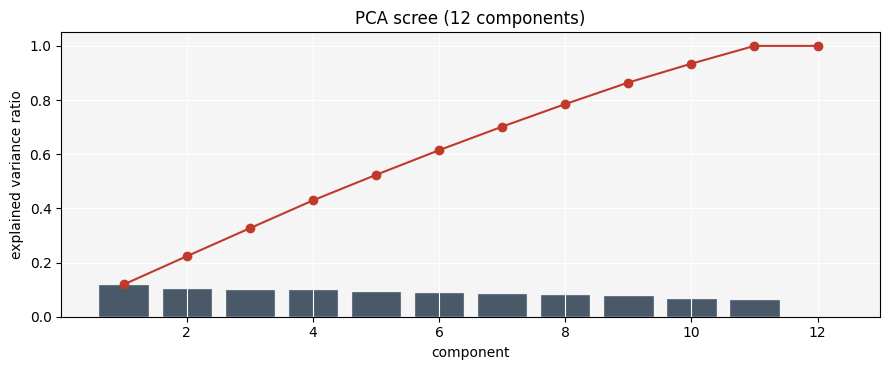

In [11]:
subset = df_meta
new_subset = pd.get_dummies(subset, columns=['design_name'], dtype='uint8')
new_subset = new_subset.drop(columns=['filename'])
print(new_subset.columns)

X = new_subset[new_subset.columns].to_numpy()

qt = QuantileTransformer(output_distribution='normal', random_state=SEED,
                         n_quantiles=min(1000, len(X)))
X_qt = qt.fit_transform(X)
sc = StandardScaler()
X_std = sc.fit_transform(X)

pca = PCA(n_components=12, random_state=SEED)
Z = pca.fit_transform(X_std)
evr = pca.explained_variance_ratio_
print('Explained variance ratio:')
for i, v in enumerate(evr):
    print(f'  PC{i + 1:2d}: {v:.3f}   cumulative={evr[:i + 1].sum():.3f}')

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(range(1, 13), evr, alpha=0.85, color='#2c3e50', edgecolor='white')
ax.plot(range(1, 13), np.cumsum(evr), marker='o', color='#c0392b')
ax.set_xlabel('component'); ax.set_ylabel('explained variance ratio')
ax.set_title('PCA scree (12 components)')
plt.tight_layout(); plt.show()

# PC loadings + recolored PC1/PC2 scatter

First: print the top-10 descriptors by absolute loading on PC1/PC2/PC3.
If the story lines up with the prediction (PC1 dominated by macro-geometry
descriptors, PC2 by scale-like ones), the manifold learner is decoration.

Second: the same PC1/PC2 scatter recolored by six metadata factors. A
factor that produces visibly separated clusters in the PC1/PC2 view is
one that the descriptors encode directly."


Top-10 |loadings| on PC1:
  +0.469  filler_insertion
  -0.433  macro_placement
  +0.401  design_name_RISCY-FPU-b
  +0.304  utilization
  +0.281  design_name_zero-riscy-b
  -0.262  design_name_RISCY-a
  -0.260  design_name_RISCY-FPU-a
  -0.249  design_name_zero-riscy-a
  +0.226  design_name_RISCY-b
  +0.081  macro_count

Top-10 |loadings| on PC2:
  +0.777  design_name_zero-riscy-a
  -0.559  design_name_RISCY-a
  -0.217  design_name_RISCY-FPU-a
  +0.109  clock_ns
  -0.092  macro_count
  +0.075  utilization
  +0.073  design_name_RISCY-b
  -0.065  design_name_RISCY-FPU-b
  -0.030  design_name_zero-riscy-b
  +0.009  power_mesh

Top-10 |loadings| on PC3:
  +0.784  design_name_RISCY-FPU-a
  -0.586  design_name_RISCY-a
  -0.195  design_name_zero-riscy-a
  +0.032  macro_placement
  -0.031  clock_ns
  +0.025  utilization
  -0.025  design_name_RISCY-b
  +0.018  design_name_RISCY-FPU-b
  +0.016  design_name_zero-riscy-b
  +0.004  macro_count


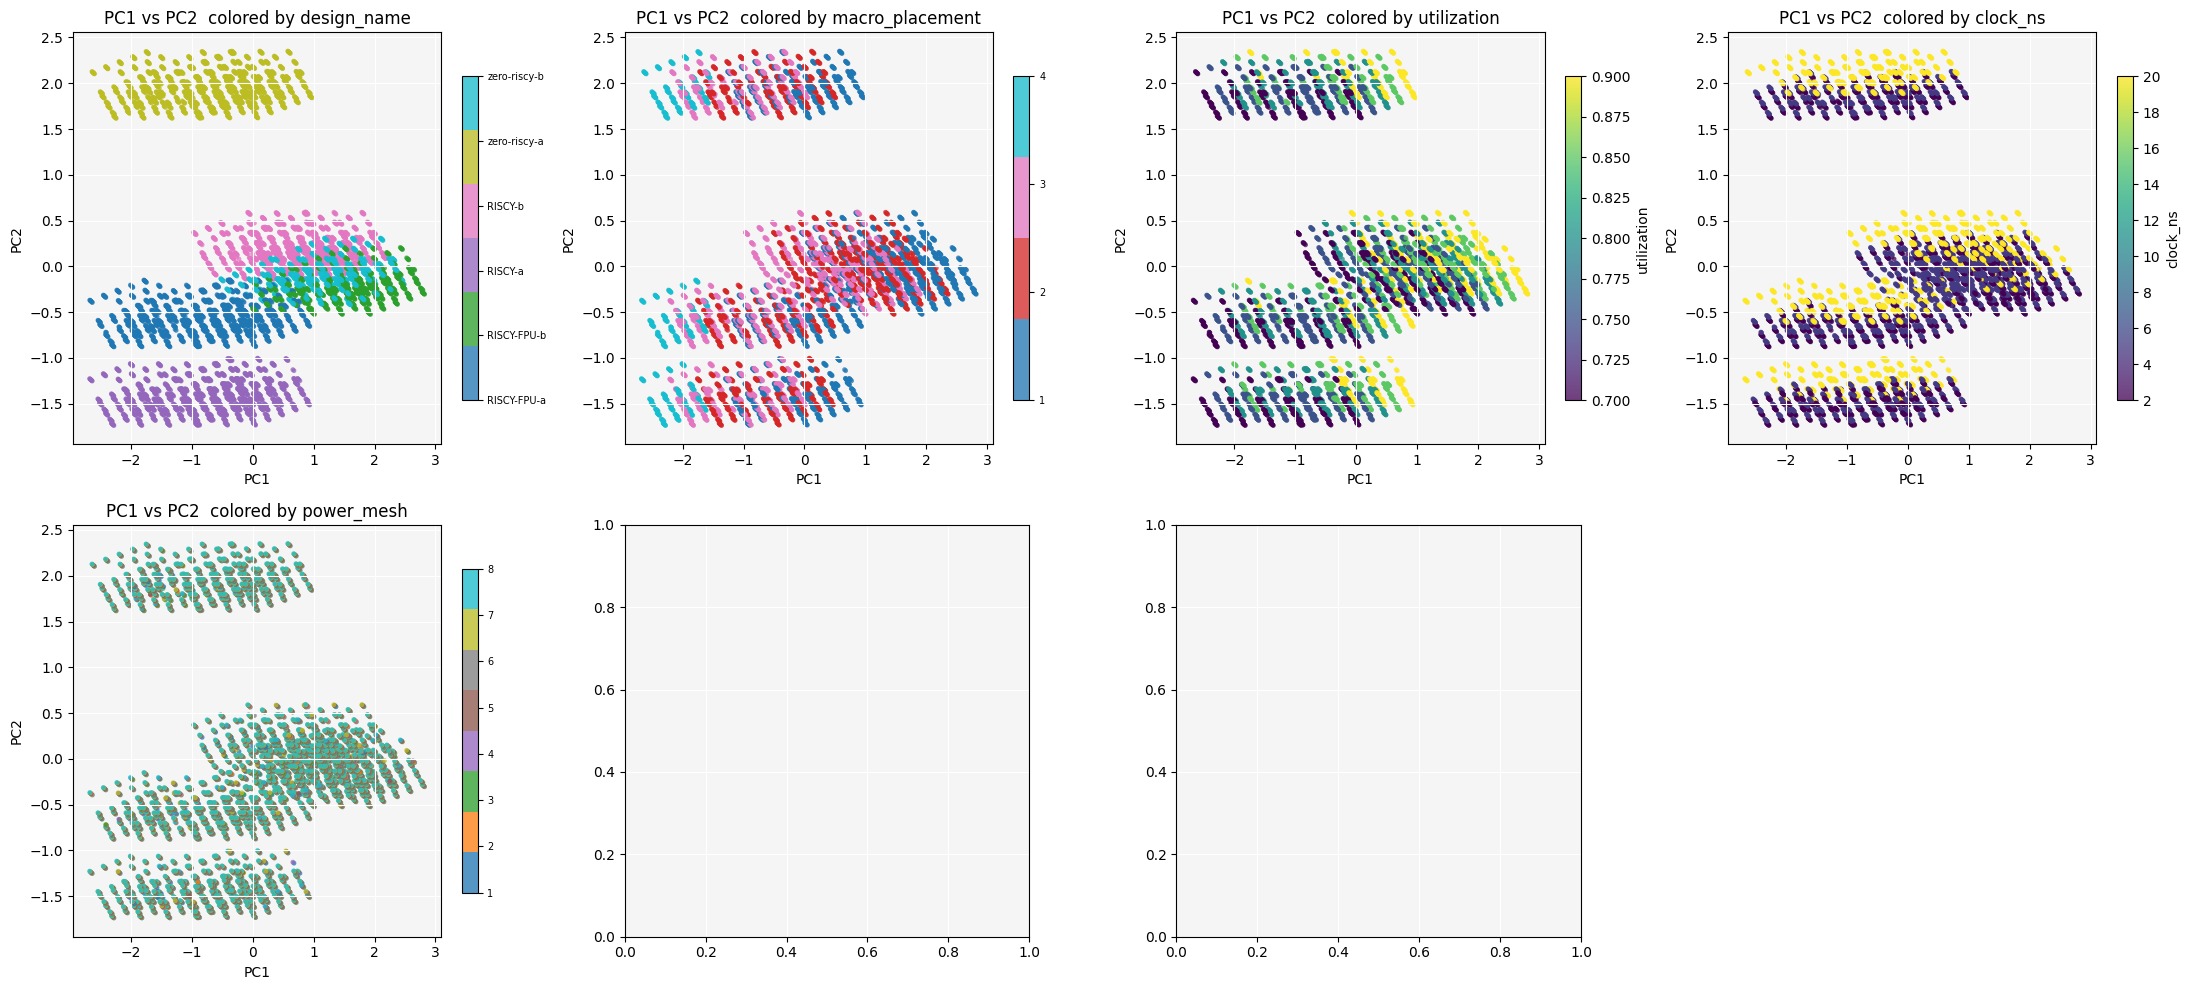

In [13]:
loadings = pd.DataFrame(pca.components_.T, index=new_subset.columns,
                        columns=[f'PC{i + 1}' for i in range(pca.n_components_)])

for pc in ['PC1', 'PC2', 'PC3']:
    top = loadings[pc].abs().sort_values(ascending=False).head(10)
    print(f'\nTop-10 |loadings| on {pc}:')
    for name in top.index:
        print(f'  {loadings.loc[name, pc]:+.3f}  {name}')

recolor_factors = ['design_name', 'macro_placement',
                   'utilization', 'clock_ns', 'power_mesh']
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, factor in zip(axes.ravel(), recolor_factors):
    if pd.api.types.is_numeric_dtype(subset[factor]):
        codes = subset[factor].to_numpy()
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], c=codes, cmap='viridis',
                         s=12, alpha=0.75, edgecolor='none')
        plt.colorbar(sc_, ax=ax, fraction=0.04, label=factor)
    else:
        levels = sorted(subset[factor].astype(str).unique())
        code_map = {l: i for i, l in enumerate(levels)}
        codes = subset[factor].astype(str).map(code_map).to_numpy()
        cmap = mcm.get_cmap('tab10' if len(levels) <= 10 else 'tab20',
                            max(len(levels), 3))
        sc_ = ax.scatter(Z[:, 0], Z[:, 1], c=codes, cmap=cmap,
                         s=12, alpha=0.75, edgecolor='none',
                         vmin=0, vmax=max(len(levels) - 1, 1))
        cbar = plt.colorbar(sc_, ax=ax, ticks=range(len(levels)), fraction=0.04)
        cbar.set_ticklabels(levels)
        cbar.ax.tick_params(labelsize=7)
    ax.set_title(f'PC1 vs PC2  colored by {factor}')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

df_full = subset

# Variance decomposition — variance-weighted η² on the leading PCs

Instead of PERMANOVA (which needs an n × n distance matrix), we compute
per-PC η² of each factor via one-way ANOVA and sum the contributions
weighted by that PC's explained variance. The `weighted_total` column\n",
approximates *fraction of layout variance explained by that factor*.\n",
Balanced design ⇒ these numbers can be read semi-quantitatively.\n",
\n",
This is the single most informative output for the client-axis question:\n",
whichever factor tops `weighted_total` is the axis the descriptors are\n",
actually structured by."

          factor  n_levels  eta2_PC1  eta2_PC2  eta2_PC3  eta2_PC4  eta2_PC5  eta2_PC6  eta2_PC7  eta2_PC8  eta2_PC9  eta2_PC10  eta2_PC11  eta2_PC12  weighted_total
     design_name         6     0.589     0.978     0.998     0.931     0.981     0.136     0.027     0.002     0.203      0.112      0.042      0.000           0.505
 macro_placement         4     0.318     0.000     0.001     0.014     0.001     0.164     0.050     0.004     0.022      0.459      0.076      0.000           0.098
        clock_ns         3     0.010     0.015     0.001     0.018     0.013     0.638     0.008     0.006     0.032      0.213      0.099      0.000           0.089
filler_insertion         2     0.315     0.000     0.000     0.057     0.004     0.126     0.000     0.000     0.074      0.012      0.412      0.000           0.089
     utilization         5     0.137     0.007     0.001     0.001     0.005     0.008     0.325     0.001     0.381      0.001      0.143      0.000           0.087
    

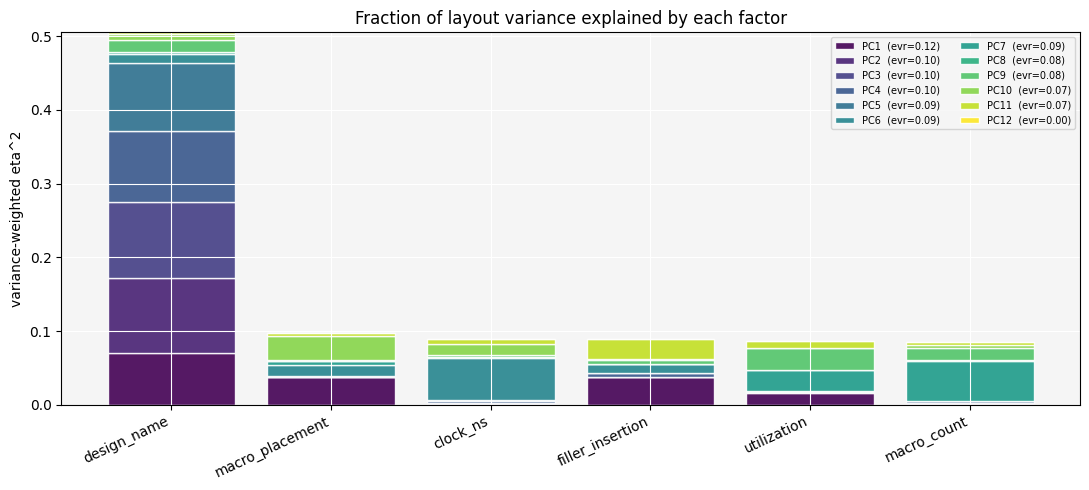

In [14]:
def eta_sq(y_num, groups):
    d = pd.DataFrame({'y': y_num, 'g': groups}).dropna()
    grand = d['y'].mean()
    ss_tot = ((d['y'] - grand) ** 2).sum()
    if ss_tot == 0:
        return 0.0
    ss_bet = sum(len(g) * (g['y'].mean() - grand) ** 2
                 for _, g in d.groupby('g'))
    return float(ss_bet / ss_tot)


K_PC = pca.n_components_
eta_rows = []
for f in FACTOR_COLS:
    if df_full[f].nunique() < 2:
        continue
    groups = df_full[f].astype(str).to_numpy()
    row = {'factor': f, 'n_levels': int(df_full[f].nunique())}
    for k in range(K_PC):
        row[f'eta2_PC{k + 1}'] = round(eta_sq(Z[:, k], groups), 3)
    row['weighted_total'] = round(sum(
        row[f'eta2_PC{k + 1}'] * evr[k] for k in range(K_PC)
    ), 3)
    eta_rows.append(row)
eta_df = pd.DataFrame(eta_rows).sort_values('weighted_total', ascending=False)
print(eta_df.to_string(index=False))

top_factors = eta_df.head(6)['factor'].tolist()
fig, ax = plt.subplots(figsize=(11, 5))
bottom = np.zeros(len(top_factors))
cmap = mcm.get_cmap('viridis', K_PC)
for k in range(K_PC):
    heights = np.array([
        eta_df.set_index('factor').loc[f, f'eta2_PC{k + 1}'] * evr[k]
        for f in top_factors
    ])
    ax.bar(top_factors, heights, bottom=bottom, color=cmap(k),
           label=f'PC{k + 1}  (evr={evr[k]:.2f})',
           edgecolor='white', alpha=0.9)
    bottom += heights
ax.set_ylabel('variance-weighted eta^2')
ax.set_title('Fraction of layout variance explained by each factor')
ax.legend(fontsize=7, loc='upper right', ncol=2)
plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.show()

# Apply K-means here